In [11]:
import os
import time
import numpy as np
import torch
from matplotlib import pyplot as plt, gridspec
from torch import nn
from torch.autograd import Variable
from tqdm import tqdm, trange
from sampling_PDE import sampling_MMPDE
import scipy.io

In [12]:
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
use_gpu = torch.cuda.is_available()
print('GPU:', use_gpu)

def is_cuda(data):
    if use_gpu:
        data = data.cuda()
    return data

GPU: True


In [13]:
def ini_sample(M, N):
    """
    生成在区域 [0,1]x[-1,1] 上的网格点。

    参数:
    M (int): [0,1] 区间上的点数。
    N (int): [-1,1] 区间上的点数。

    返回:
    numpy.ndarray: 形状为 (M*N, 2) 的数组，每行表示一个点的 (t, x) 坐标。
    """
    t = np.linspace(0, 1, M+1)
    t = t[0:-1]
    x = np.linspace(-1, 1, N)
    #x = x[1:-1]
    T, X = np.meshgrid(t, x, indexing='ij')
    grid = np.column_stack((T.ravel(), X.ravel()))
    print('original samples:', grid)
    temp = torch.from_numpy(grid).float()  # numpy to tensor float32
    #print(temp.requires_grad)
    if use_gpu:
        temp = temp.cuda()
    return temp



def sampling_for_equ(grid_tensor):
    """
    去除边界值和初值

    参数:
    grid_tensor (torch.Tensor): 形状为 (M*N, 2) 的网格点张量

    返回:
    torch.Tensor: 过滤后的张量，形状为 (K, 2)，K <= M*N
    """
    # 创建非边缘点的布尔掩码（使用容差避免浮点精度问题）

    grid_tensor = grid_tensor[Nbc:, :]   # delete initials
    y_values = grid_tensor[:, 1]
    mask = ~(torch.isclose(y_values, torch.tensor(-1.0), atol=1e-8) |
             torch.isclose(y_values, torch.tensor(1.0), atol=1e-8))

    return grid_tensor[mask]

In [14]:
class Net_u(nn.Module):
    def __init__(self, layers):
        super(Net_u, self).__init__()
        self.layers = layers
        self.iter = 0
        self.activation = nn.Tanh()
        self.linear = nn.ModuleList([nn.Linear(layers[i], layers[i + 1]) for i in range(len(layers) - 1)])
        for i in range(len(layers) - 1):
            nn.init.xavier_normal_(self.linear[i].weight.data, gain=1.0)
            nn.init.zeros_(self.linear[i].bias.data)

    def forward(self, x):
        if not torch.is_tensor(x):
            x = torch.from_numpy(x)
        a = self.activation(self.linear[0](x))
        for i in range(1, len(self.layers) - 2):
            z = self.linear[i](a)
            a = self.activation(z)
        a = self.linear[-1](a)
        return a

In [15]:
def U_tt(x, t):
    return - 25 * torch.pi ** 2 * x * torch.cos(5 * torch.pi * t) + 6 * t * x ** 3


def U_xx(x, t):
    return 6 * x * t ** 3


def PDE_f1(x, t):
    return U_tt(x, t) + a * U_xx(x, t) + b * PDE_u(x, t) + c * PDE_u(x, t) ** k


def PDE_u(x, t):
    return x * torch.cos(5 * torch.pi * t) + (x * t) ** 3


def PDE_loss_fun(x, train_U):
    if not x.requires_grad:
        x = Variable(x, requires_grad=True)
    u = train_U(x)
    d = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)
    u_t = d[0][:, 0].unsqueeze(-1)
    u_x = d[0][:, 1].unsqueeze(-1)
    u_tt = torch.autograd.grad(u_t, x, grad_outputs=torch.ones_like(u_t), create_graph=True)[0][:, [0]]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0][:, [1]]
    t = x[:, [0]]
    x1 = x[:, [1]]
    f = u_tt + a * u_xx + b * u + c * u ** k - (
        PDE_f1(x1, t)
    )
    return f

In [16]:
class Model:
    def __init__(self, net, x_bc, u_bc, x_ic, u_ic,
                 PDE_loss_fun,
                 x_test, u_test_exact, 
                 nu):

        self.x_ic_s = None
        self.x_bc_s = None
        self.x_f_s = None
        self.s_collect = []

        self.optimizer_LBGFS = None
        self.net = net

        self.x_bc = x_bc
        self.u_bc = u_bc

        self.x_ic = x_ic
        self.u_ic = u_ic

        self.x_sample = None

        self.PDE_loss_fun = PDE_loss_fun  #equation loss

        self.x_test = x_test
        self.u_test_exact = u_test_exact
        
        self.nu = nu

        self.start_loss_collect = False
        self.x_label_loss_collect = []
        self.x_f_loss_collect = []
        self.x_test_estimate_collect = []

    def train_U(self, x):
        return self.net(x)

    def predict_U(self, x):
        return self.train_U(x)

    def true_loss(self, loss_e, loss_ic, loss_bc):
        return (torch.exp(-self.x_f_s.detach()) * loss_e + torch.exp(-self.x_ic_s.detach()) * loss_ic +
                torch.exp(-self.x_bc_s.detach()) * loss_bc)

    # compute backward loss
    def epoch_loss(self):

        x_f = sampling_for_equ(self.x_sample)   #delete initial and boundaries
        #print('samples for equ:', x_f)
        loss_equation = torch.mean(self.PDE_loss_fun(x_f, self.train_U) ** 2)

        loss_ic = torch.mean((self.train_U(self.x_ic) - self.u_ic) ** 2)

        loss_bc = torch.mean((self.train_U(self.x_bc) - self.u_bc) ** 2)

        # if self.start_loss_collect:
        #     self.x_f_loss_collect.append([self.net.iter, loss_equation.item()])
        #     self.x_label_loss_collect.append([self.net.iter, loss_label.item()])
        return loss_equation, loss_ic, loss_bc

    # compute backward loss
    def LBGFS_epoch_loss(self):
        self.optimizer_LBGFS.zero_grad()
        #x_f = self.x_sample
        x_f = sampling_for_equ(self.x_sample)  # delete initial and boundaries
        loss_equation = torch.mean(self.PDE_loss_fun(x_f, self.train_U) ** 2)

        loss_ic = torch.mean((self.train_U(self.x_ic) - self.u_ic) ** 2)

        loss_bc = torch.mean((self.train_U(self.x_bc) - self.u_bc) ** 2)

        # if self.start_loss_collect:
        #     self.x_f_loss_collect.append([self.net.iter, loss_equation.item()])
        #     self.x_label_loss_collect.append([self.net.iter, loss_label.item()])

        loss = self.true_loss(loss_equation, loss_ic, loss_bc)
        loss.backward(retain_graph=True)
        self.net.iter += 1
        if self.net.iter % 100  == 0:
           print('Iter:', self.net.iter, 'PDE_Loss:', loss.item())
        #print('loss of equ:', loss_equation, 'loss of initial:', loss_ic, 'loss of boundary:', loss_bc)

        return loss

    def evaluate(self):
        pred = self.train_U(self.x_test).cpu().detach().numpy()
        print('predict:', pred)
        exact = self.u_test_exact.cpu().detach().numpy()
        print('exact:', exact)
        error = np.linalg.norm(pred - exact, 2) / np.linalg.norm(exact, 2)
        return error  #function  L_2 error



    def run_AM(self):

        for move_count in range(M_num):
            self.optimizer_LBGFS = torch.optim.LBFGS(self.net.parameters(), lr=lbgfs_lr,
                                                     max_iter=lbgfs_iter)
            optimizer_adam = torch.optim.Adam(self.net.parameters(), lr=adam_lr)
            pbar = trange(adam_iter, ncols=100)


            # extract initial points from samples
            #t_zero_mask = torch.isclose(self.x_sample[:, 0], torch.tensor(0.0))
            # self.x_ic = self.x_sample[0:Nbc, :]
            #print('samples at $t_0$:', self.x_ic)
            # self.u_ic = ini_fun(self.x_ic)

            for i in pbar:
                optimizer_adam.zero_grad()
                loss_e, loss_ic, loss_bc = self.epoch_loss()
                loss = self.true_loss(loss_e, loss_ic, loss_bc)
                loss.backward(retain_graph=True)
                self.net.iter += 1
                optimizer_adam.step()
                pbar.set_postfix({'Iter': self.net.iter,
                                  'PDE_Loss': '{0:.2e}'.format(loss.item())
                                  })

            print('solve PDE Adam done!')
            self.optimizer_LBGFS.step(self.LBGFS_epoch_loss)
            print('solve PDE LBGFS done!')

            # model predict after one time sampling
            error = self.evaluate()
            print('change_counts', move_count, 'PDE_Test_L2error:', '{0:.2e}'.format(error))
            self.x_test_estimate_collect.append([move_count, '{0:.2e}'.format(error)])


            ## adaptive sampling

            #u = self.train_U(self.x_sample)
            #print('the pde solution:', u)
            #if not self.x_sample.requires_grad:
            x_init = Variable(self.x_sample, requires_grad=True)
            #u = self.train_U(x_init)
            #print('u in learn pde:', u)
            #dx = torch.autograd.grad(u, x_init, grad_outputs=torch.ones_like(u), create_graph=True)[0]
            #grad_t = dx[:, [0]] #du/dt
            #grad_x = dx[:, [1]] #du/dx  size([,1])
            #print('dx:', grad_x)

            
            model_sampling = sampling_MMPDE(x_init, self.train_U, layers_p, lb, ub, self.nu, adam_iter_MM, lbgfs_iter_MM)
            self.x_sample = model_sampling.train()
            if not self.x_sample.requires_grad:
                self.x_sample = Variable(self.x_sample, requires_grad=True)
            #print('new_sample', type(self.x_sample))
            self.nu = self.nu / 2

            '''
            x_init = random_fun(100000)
            x = Variable(x_init, requires_grad=True)
            u = self.train_U(x)
            dx = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
            grad_x1 = dx[:, [0]].squeeze()
            grad_x2 = dx[:, [1]].squeeze()
            dx = torch.sqrt(1 + grad_x1 ** 2 + grad_x2 ** 2).cpu().detach().numpy()
            err_dx = np.power(dx, AM_K) / np.power(dx, AM_K).mean()
            p = (err_dx / sum(err_dx))
            X_ids = np.random.choice(a=len(x_init), size=M, replace=False, p=p)
            self.x_f_M = x_init[X_ids]
            '''



    def train(self):

        self.x_sample = ini_sample(Nic, Nbc)  # initialize samples, x_sample.require_grad = false


        self.x_f_s = is_cuda(torch.tensor(0.).float())   # weight: loss of equation
        self.x_ic_s = is_cuda(torch.tensor(0.).float())  # weight: loss of initial condition
        self.x_bc_s = is_cuda(torch.tensor(0.).float())  # weight: loss of boundary condition

        start_time = time.time()
        if model_type == 0:
            self.run_baseline()
        elif model_type == 1:
            self.run_AM()

        elapsed = time.time() - start_time
        print('Training time: %.2f' % elapsed)

In [17]:
def draw_solution():

    ## plot exact solution
    u_test_np = u_test_exact.cpu().detach().numpy()
    TT, XX = np.meshgrid(t, x)
    e = np.reshape(u_test_np, (TT.shape[0], TT.shape[1]))
    plt.pcolor(TT, XX, e, cmap='jet')
    plt.colorbar()
    plt.xlabel('$t$', fontsize=20)
    plt.ylabel('$x$', fontsize=20)
    plt.title(r'Exact $u(x,t)$', fontsize=20)
    plt.tight_layout()
    # plt.savefig('burgers_exact.pdf')
    plt.show()


    ## plot model prediction
    e = np.reshape(predict_u, (TT.shape[0], TT.shape[1]))
    plt.pcolor(TT, XX, e, cmap='jet')
    plt.colorbar()
    plt.xlabel('$t$', fontsize=20)
    plt.ylabel('$x$', fontsize=20)
    plt.title(r'MMPDE $u(S,t)$', fontsize=20)
    plt.tight_layout()
    # plt.savefig('burgers_pred.pdf')
    plt.show()
    
    
    ## plot model prediction absolute error
    e = np.reshape(abs(predict_u-u_test_np), (TT.shape[0], TT.shape[1]))
    plt.pcolor(TT, XX, e, cmap='jet')
    plt.colorbar()
    plt.xlabel('$t$', fontsize=20)
    plt.ylabel('$x$', fontsize=20)
    plt.title(r'absolute error of MMPDE $u(S,t)$', fontsize=20)
    plt.tight_layout()
    #plt.savefig('burgers_pred.pdf')
    plt.show()
    
    

def draw_residual():
    f = PDE_loss_fun(x_test, model.train_U)
    f = f.cpu().detach().numpy()
    print('residuals:', f)
    XX1, XX2 = np.meshgrid(t, x)
    e = np.reshape(abs(f), (XX1.shape[0], XX2.shape[1]))
    plt.pcolor(XX1, XX2, e, shading='auto', cmap='jet')
    plt.colorbar()
    plt.xlabel('$t$', fontsize=20)
    plt.ylabel('$x$', fontsize=20)
    plt.title(r'Residual', fontsize=20)
    plt.tight_layout()
    # plt.savefig('burgers_residual_MMPDE.pdf')
    plt.show()



def draw_points(points, old_points=None):

    if old_points is not None:
        adds = old_points.cpu().detach().numpy()
        plt.plot(adds[:, [0]], adds[:, [1]], 'kx', markersize=4, clip_on=False)

    #points = points.cpu().detach().numpy()
    plt.plot(points[:, [0]], points[:, [1]], 'rx', markersize=1)
    plt.xlim(-0.1, 1.1)
    plt.ylim(-0.1, 1.1)
    plt.xlabel('$t$', fontsize=20)
    plt.ylabel('$x$', fontsize=20)
    plt.title(r'points distribution', fontsize=20)
    # plt.savefig('burgers_new_points.pdf')  # points distribution
    plt.show()


    xi_pred = points[:,1]   # predict of x:[Nic*Nbc,2]
    xi_new = xi_pred.reshape((Nic, Nbc), order='C')   # predict of x:[Nic,Nbc]


    x_t0 = xi_new[0, :].flatten()[:, None]
    plt.xlim(-1.1, 1.1)
    plt.ylim(-0.5, 0.5)
    plt.xlabel('$x$', fontsize=20)
    plt.plot(x_t0, 0 * x_t0, 'bo', markersize=1)
    plt.title(r'points distribution at $t_0$', fontsize=20)
    # plt.savefig('burgers_new_points_t0.pdf')  # points distribution at initial time
    plt.show()

    x_t = xi_new[-1, :].flatten()[:, None]
    plt.xlim(-1.1, 1.1)
    plt.ylim(-1, 1)
    plt.plot(x_t, 0 * x_t, 'bo', markersize=1)  # points distribution at end time
    plt.title(r'points distribution at $t_T$', fontsize=20)
    plt.xlabel('$x$', fontsize=20)
    # plt.savefig('burgers_new_points_Tend.pdf')
    plt.show()



    ## plot the trajectaries of the left and right points (except the boundary points)
    xi_0 = xi_new[:, 50].flatten()[:, None]
    xi_end = xi_new[:, Nbc-10].flatten()[:, None]
    plt.plot(t.flatten()[:, None], xi_0, markersize=1)
    plt.plot(t.flatten()[:, None], xi_end, markersize=1)
    plt.title(r'points trajectaries of the left and right points', fontsize=20)
    plt.xlim(-0.1, 1.1)
    plt.ylim(-1, 1)
    plt.xlabel('$t$', fontsize=20)
    plt.ylabel('$x$', fontsize=20)
    # plt.savefig('burgers_new_points.pdf')
    plt.show()



In [18]:
if __name__ == '__main__':
    lb = np.array([0.0, 0.0]) #u[t,x]
    ub = np.array([1.0, 1.0])

    layers_u = [2, 40, 40, 40, 40, 1]
    net = is_cuda(Net_u(layers_u))


    adam_iter, lbgfs_iter = 5000, 50000
    adam_lr, lbgfs_lr = 0.001, 0.5

    adam_iter_MM, lbgfs_iter_MM = 2000, 0

    model_type = 1  # 0:baseline 1:AM


    M_num = 2  # number of moving samples

    layers_p = [2, 20, 20,20, 20, 20, 20, 20,20, 1]  # layers of the sampling network





    ##### training points

    ## number of training points
    Nic = 100  # number of t
    Nbc = 100  # number of x

    ####### test data
    nu = 0.1

    k = 3
    a = -1
    b = 0
    c = 1
    
    exact_u = lambda x: x[:, [1]] * np.cos(5 * np.pi * x[:, [0]]) + np.power(x[:, [1]] * x[:, [0]], 3)

    t = np.expand_dims(np.linspace(0, 1, 100), axis=1)
    x = np.expand_dims(np.linspace(0, 1, 100), axis=1)
    X1, X2 = np.meshgrid(t, x)

    x_test_np = np.concatenate((np.vstack(np.expand_dims(X1, axis=2)), np.vstack(np.expand_dims(X2, axis=2))), axis=-1)
    solution = exact_u(x_test_np)
    x_test = is_cuda(torch.from_numpy(x_test_np).float())
    u_test_exact = is_cuda(torch.from_numpy(solution).float())
    ########################

    ###### ic data,  do resample during training
    
    x_init = torch.from_numpy(x).float()
    x_initial = torch.cat((torch.zeros(Nic, 1), x_init), dim=1)
    x_boundary_left = torch.cat((torch.rand([Nbc, 1]), torch.full([Nbc, 1], 0)), dim=1)
    x_boundary_right = torch.cat((torch.rand([Nbc, 1]), torch.ones([Nbc, 1])), dim=1)

    x_initial_label = torch.from_numpy(exact_u(x_initial.numpy())).float()
    x_boundary_left_label = torch.from_numpy(exact_u(x_boundary_left.numpy())).float()
    x_boundary_right_label = torch.from_numpy(exact_u(x_boundary_right.numpy())).float()

    x_ic = is_cuda(x_initial)
    u_ic = is_cuda(x_initial_label)
    x_bc = is_cuda(torch.cat((x_boundary_left, x_boundary_right), dim=0))
    u_bc = is_cuda(torch.cat((x_boundary_left_label, x_boundary_right_label), dim=0))
    #######################



In [19]:
model = Model(
    net=net,
    x_bc=x_bc,
    u_bc=u_bc,
    x_ic=x_ic,
    u_ic=u_ic,
    PDE_loss_fun=PDE_loss_fun,
    x_test=x_test,
    u_test_exact=u_test_exact,
    nu = nu
    )

model.train()
print(model.x_test_estimate_collect)

original samples: [[ 0.         -1.        ]
 [ 0.         -0.97979798]
 [ 0.         -0.95959596]
 ...
 [ 0.99        0.95959596]
 [ 0.99        0.97979798]
 [ 0.99        1.        ]]


100%|█████████████████████████████| 5000/5000 [00:50<00:00, 99.34it/s, Iter=5000, PDE_Loss=1.57e+01]


solve PDE Adam done!
Iter: 5100 PDE_Loss: 14.785026550292969
Iter: 5200 PDE_Loss: 13.785955429077148
Iter: 5300 PDE_Loss: 12.761642456054688
Iter: 5400 PDE_Loss: 11.32828426361084
Iter: 5500 PDE_Loss: 8.606968879699707
Iter: 5600 PDE_Loss: 6.244657516479492
Iter: 5700 PDE_Loss: 4.530375003814697
Iter: 5800 PDE_Loss: 3.66835880279541
Iter: 5900 PDE_Loss: 3.132967948913574
Iter: 6000 PDE_Loss: 2.7004218101501465
Iter: 6100 PDE_Loss: 1.9885752201080322
Iter: 6200 PDE_Loss: 0.8344724178314209
Iter: 6300 PDE_Loss: 0.3444485664367676
Iter: 6400 PDE_Loss: 0.1926591396331787
Iter: 6500 PDE_Loss: 0.11935248225927353
Iter: 6600 PDE_Loss: 0.08934354782104492
Iter: 6700 PDE_Loss: 0.06797321140766144
Iter: 6800 PDE_Loss: 0.053286440670490265
Iter: 6900 PDE_Loss: 0.04504123330116272
Iter: 7000 PDE_Loss: 0.03926893696188927
Iter: 7100 PDE_Loss: 0.03487853333353996
Iter: 7200 PDE_Loss: 0.030787955969572067
Iter: 7300 PDE_Loss: 0.027937766164541245
Iter: 7400 PDE_Loss: 0.025213738903403282
Iter: 7500 P

100%|████████████████████████████| 5000/5000 [00:51<00:00, 97.18it/s, Iter=30784, PDE_Loss=9.04e+00]


solve PDE Adam done!
Iter: 30800 PDE_Loss: 0.019895581528544426
Iter: 30900 PDE_Loss: 0.0076827662996947765
Iter: 31000 PDE_Loss: 0.005218755919486284
Iter: 31100 PDE_Loss: 0.0038675989490002394
Iter: 31200 PDE_Loss: 0.0030008426401764154
Iter: 31300 PDE_Loss: 0.002368996851146221
Iter: 31400 PDE_Loss: 0.002154104644432664
Iter: 31500 PDE_Loss: 0.0019033397547900677
Iter: 31600 PDE_Loss: 0.0017761029303073883
Iter: 31700 PDE_Loss: 0.0016391982790082693
Iter: 31800 PDE_Loss: 0.0014905432472005486
Iter: 31900 PDE_Loss: 0.0013832009863108397
Iter: 32000 PDE_Loss: 0.001317610964179039
Iter: 32100 PDE_Loss: 0.0012456146068871021
Iter: 32200 PDE_Loss: 0.0011736609740182757
Iter: 32300 PDE_Loss: 0.0011203903704881668
Iter: 32400 PDE_Loss: 0.0010584958363324404
Iter: 32500 PDE_Loss: 0.0010284263407811522
Iter: 32600 PDE_Loss: 0.0009759810054674745
Iter: 32700 PDE_Loss: 0.0009347798186354339
Iter: 32800 PDE_Loss: 0.0009115853463299572
Iter: 32900 PDE_Loss: 0.0008823951939120889
Iter: 33000 PDE_

[[0, '9.81e-02'], [1, '7.72e-02']]


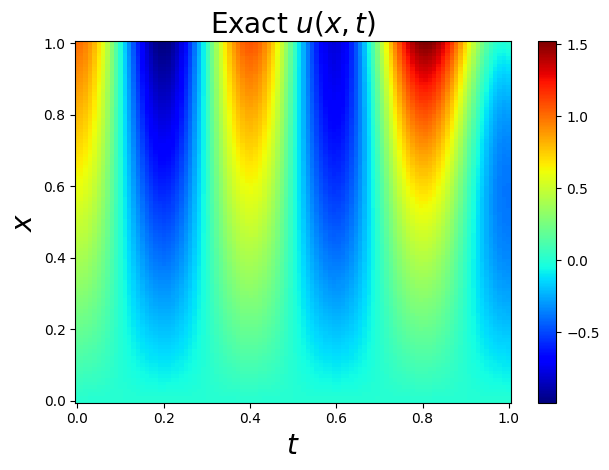

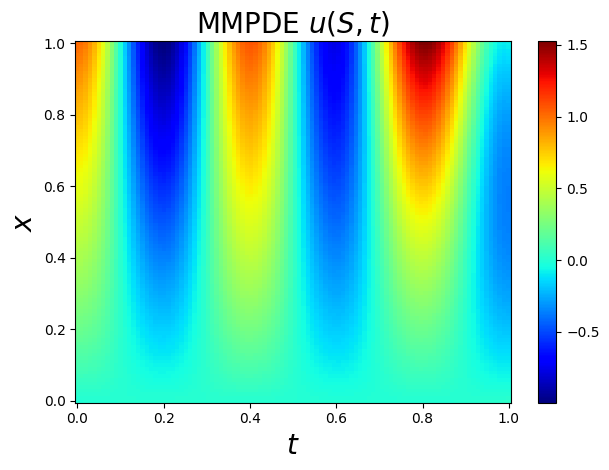

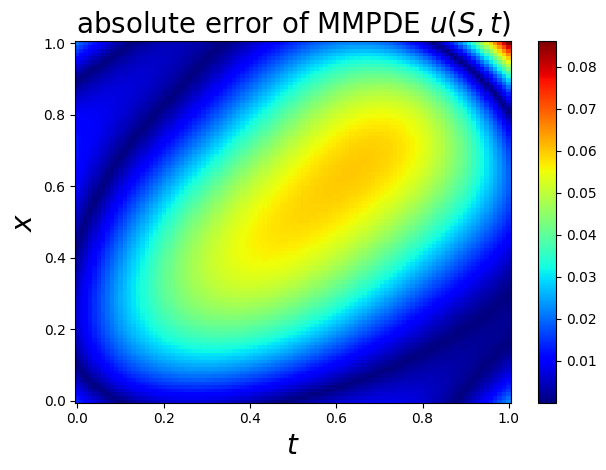

residuals: [[ 0.11130339]
 [ 0.02970308]
 [-0.00729857]
 ...
 [-0.03012085]
 [-0.43051147]
 [-1.5175934 ]]


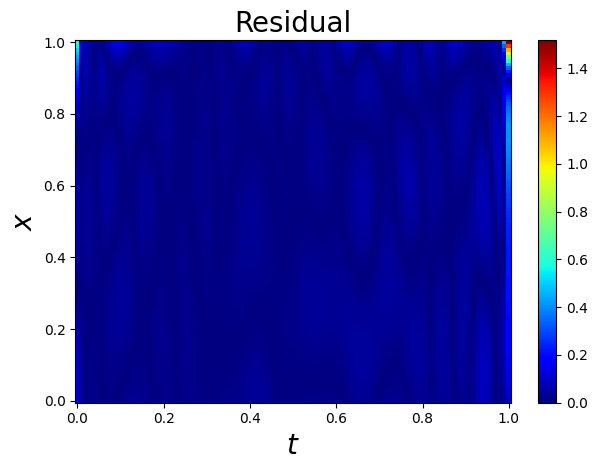

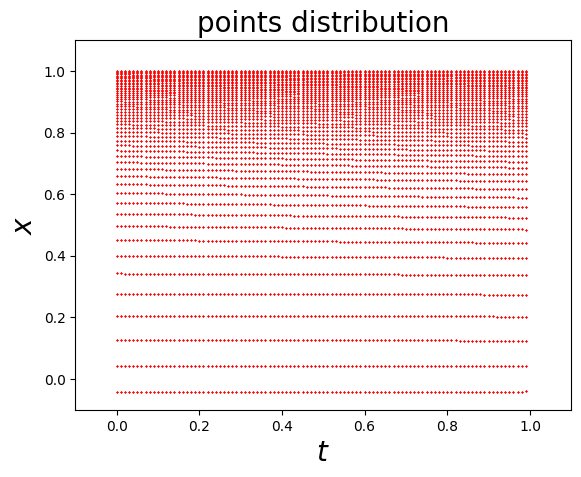

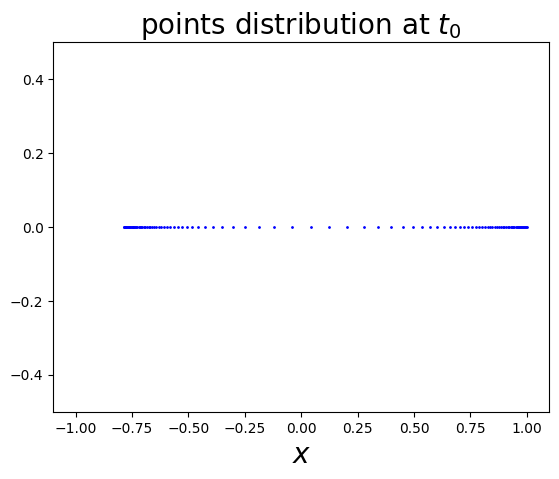

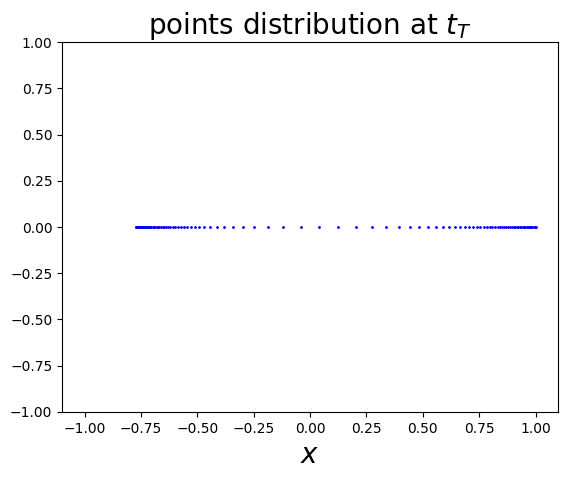

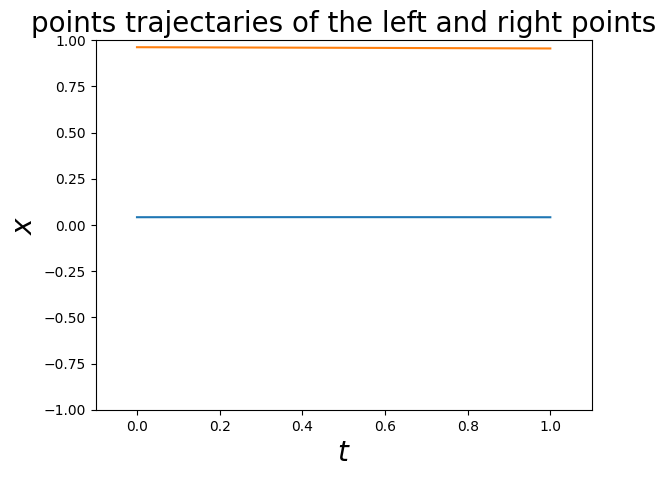

In [20]:
## model prediction
predict_u = model.predict_U(x_test).cpu().detach().numpy()
scipy.io.savemat('u_pred.mat', {'u_pred': predict_u})
print(model.x_test_estimate_collect)

draw_solution()

draw_residual()

## adaptive sampling location
x_predict = model.x_sample.cpu().detach().numpy()
scipy.io.savemat('x_predict.mat', {'x_pred': x_predict})

draw_points(x_predict)